# Toxic Comment Classification Challenge

This notebook contains the complete project for the Toxic Comment Classification challenge. It includes custom implementations of LSTM, BiLSTM, GRU, RCNN, and Transformer models from scratch, along with optimizations like Class-Weighted Loss, AdamW, Gradient Clipping, and Learning Rate Scheduling.


## 1. Setup & Imports


In [1]:
!pip install -q transformers tqdm scikit-learn pandas numpy matplotlib

import os
import math
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report, accuracy_score
from transformers import AutoTokenizer


## 2. Configuration & Constants
Configure your paths and hyperparameters here.


In [2]:
# Local paths (use datasets/ directory)
DATA_DIR = "/kaggle/input/datasets/duongvucongtuan/toxic-comment-classfiication-jigsaw-competition"
TRAIN_CSV_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_CSV_PATH = os.path.join(DATA_DIR, "test.csv")
SUBMISSION_CSV_PATH = "submission.csv"

LABEL_COLUMNS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
TEXT_COLUMN = 'comment_text'

# ========== Core Hyperparameters ==========
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EPOCHS = 10          # Early Stopping will handle when to really stop
MAX_LEN = 128
EMBEDDING_DIM = 128
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.3

# ========== Optimization Hyperparameters ==========
WEIGHT_DECAY = 1e-4            # L2 regularization strength for AdamW
WARMUP_RATIO = 0.1             # 10% of total steps used for LR warmup
EARLY_STOPPING_PATIENCE = 3    # Stop after 3 epochs without improvement
GRADIENT_CLIP_MAX_NORM = 1.0   # Maximum gradient norm for clipping

# Model type identifiers
BILSTM_MODEL = 'bilstm'
ATTENTION_BILSTM_MODEL = 'attention_bilstm'
LSTM_MODEL = 'lstm'
GRU_MODEL = 'gru'
RCNN_MODEL = 'rcnn'
TRANSFORMER_MODEL = 'transformer'


## 3. Utilities (Metrics, LR Scheduler, Early Stopping)


In [3]:
def compute_metrics(all_labels: np.ndarray, all_probs: np.ndarray, threshold: float = 0.5):
    all_preds = (all_probs >= threshold).astype(int)
    metrics = {}
    
    try:
        metrics['roc_auc_macro'] = roc_auc_score(all_labels, all_probs, average='macro')
        metrics['roc_auc_per_class'] = roc_auc_score(all_labels, all_probs, average=None)
    except ValueError:
        metrics['roc_auc_macro'] = 0.0
        metrics['roc_auc_per_class'] = np.zeros(all_labels.shape[1])

    metrics['f1_macro'] = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    metrics['f1_micro'] = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    metrics['precision_macro'] = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    metrics['recall_macro'] = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    metrics['subset_accuracy'] = accuracy_score(all_labels, all_preds)
    return metrics

def print_classification_report(all_labels: np.ndarray, all_probs: np.ndarray,
                                 label_names: list, threshold: float = 0.5):
    all_preds = (all_probs >= threshold).astype(int)
    print("\n" + "=" * 60)
    print("CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(all_labels, all_preds, target_names=label_names, zero_division=0))
    
    try:
        per_class_auc = roc_auc_score(all_labels, all_probs, average=None)
        print("\nPer-Class ROC-AUC:")
        for name, auc in zip(label_names, per_class_auc):
            print(f"  {name:20s}: {auc:.4f}")
        print(f"  {'MACRO AVERAGE':20s}: {np.mean(per_class_auc):.4f}")
    except ValueError:
        print("\nCould not compute per-class AUC (possibly missing classes in batch)")
    print("=" * 60)


class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0, mode: str = 'min', verbose: bool = True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, score, model):
        current_score = -score if self.mode == 'min' else score

        if self.best_score is None:
            self.best_score = current_score
            self._save_checkpoint(model)
        elif current_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"  ⏳ EarlyStopping: {self.counter}/{self.patience} (no improvement)")
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"  🛑 EarlyStopping triggered! Restoring best model...")
                self._restore_checkpoint(model)
        else:
            if self.verbose:
                print(f"  ✅ EarlyStopping: metric improved")
            self.best_score = current_score
            self.counter = 0
            self._save_checkpoint(model)
        return self.early_stop

    def _save_checkpoint(self, model):
        self.best_model_state = copy.deepcopy(model.state_dict())

    def _restore_checkpoint(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)


class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_steps: int, total_steps: int, min_lr_ratio: float = 0.0):
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.min_lr_ratio = min_lr_ratio
        self.scheduler = LambdaLR(optimizer, lr_lambda=self._lr_lambda)

    def _lr_lambda(self, step):
        if step < self.warmup_steps:
            return float(step) / float(max(1, self.warmup_steps))
        else:
            progress = float(step - self.warmup_steps) / float(max(1, self.total_steps - self.warmup_steps))
            cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
            return self.min_lr_ratio + (1.0 - self.min_lr_ratio) * cosine_decay

    def step(self):
        self.scheduler.step()

    def get_last_lr(self):
        return self.scheduler.get_last_lr()


## 4. Preprocessing & Dataset


In [4]:
class TextProcessor:
    def __init__(self, model_name="distilbert-base-uncased", max_len=128):
        self.model_name = model_name
        self.max_len = max_len
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize(self, texts, return_tensors="pt"):
        if isinstance(texts, str):
            texts = [texts]
        elif isinstance(texts, pd.Series):
            texts = texts.fillna("").tolist()
        elif isinstance(texts, list):
            texts = [str(t) if t is not None else "" for t in texts]

        return self.tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors=return_tensors
        )


class ToxicDataset(Dataset):
    def __init__(self, df, processor, text_column=TEXT_COLUMN, label_columns=LABEL_COLUMNS):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.text_column = text_column
        self.label_columns = label_columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row[self.text_column]) if pd.notnull(row[self.text_column]) else ""

        if all(col in self.df.columns for col in self.label_columns):
            labels = torch.tensor(row[self.label_columns].values.astype(float), dtype=torch.float)
        else:
            labels = torch.tensor([])

        encoding = self.processor.tokenize(text, return_tensors="pt")

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': labels
        }


## 5. Model Core Components (Cells & Attention)


In [5]:
class OwnLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(OwnLSTMCell, self).__init__()
        self.hidden_size = hidden_size
        self.W_ih = nn.Parameter(torch.Tensor(input_size, 4 * hidden_size))
        self.W_hh = nn.Parameter(torch.Tensor(hidden_size, 4 * hidden_size))
        self.b_ih = nn.Parameter(torch.Tensor(4 * hidden_size))
        self.b_hh = nn.Parameter(torch.Tensor(4 * hidden_size))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.orthogonal_(self.W_ih)
        nn.init.orthogonal_(self.W_hh)
        nn.init.zeros_(self.b_ih)
        nn.init.zeros_(self.b_hh)

    def forward(self, x, states):
        h_prev, c_prev = states
        gates = (torch.matmul(x, self.W_ih) + self.b_ih) + (torch.matmul(h_prev, self.W_hh) + self.b_hh)
        i_gate, f_gate, g_gate, o_gate = gates.chunk(4, 1)

        i_gate = torch.sigmoid(i_gate)
        f_gate = torch.sigmoid(f_gate)
        g_gate = torch.tanh(g_gate)
        o_gate = torch.sigmoid(o_gate)

        c_next = f_gate * c_prev + i_gate * g_gate
        h_next = o_gate * torch.tanh(c_next)
        return h_next, c_next


class OwnGRUCell(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super(OwnGRUCell, self).__init__()
        self.hidden_size = hidden_size
        self.W_ih = nn.Parameter(torch.Tensor(input_size, 2 * hidden_size))
        self.W_hh = nn.Parameter(torch.Tensor(hidden_size, 2 * hidden_size))
        self.b_ih = nn.Parameter(torch.Tensor(2 * hidden_size))
        self.b_hh = nn.Parameter(torch.Tensor(2 * hidden_size))
        self.W_in = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.W_hn = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_in = nn.Parameter(torch.Tensor(hidden_size))
        self.b_hn = nn.Parameter(torch.Tensor(hidden_size))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.orthogonal_(self.W_ih); nn.init.orthogonal_(self.W_hh)
        nn.init.orthogonal_(self.W_in); nn.init.orthogonal_(self.W_hn)
        nn.init.zeros_(self.b_ih); nn.init.zeros_(self.b_hh)
        nn.init.zeros_(self.b_in); nn.init.zeros_(self.b_hn)

    def forward(self, x, h_prev):
        gates = (torch.matmul(x, self.W_ih) + self.b_ih) + (torch.matmul(h_prev, self.W_hh) + self.b_hh)
        z_gate, r_gate = gates.chunk(2, 1)
        z_gate, r_gate = torch.sigmoid(z_gate), torch.sigmoid(r_gate)
        n_gate = torch.tanh((torch.matmul(x, self.W_in) + self.b_in) + r_gate * (torch.matmul(h_prev, self.W_hn) + self.b_hn))
        h_next = (1 - z_gate) * n_gate + z_gate * h_prev
        return h_next


class SelfAttention(nn.Module):
    def __init__(self, hidden_size):
        super(SelfAttention, self).__init__()
        self.projection = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden_states, mask=None):
        energy = torch.tanh(self.projection(hidden_states))
        weights = self.v(energy)
        if mask is not None:
            mask = mask.unsqueeze(-1).float()
            weights = weights.masked_fill(mask == 0, -1e9)
        weights = F.softmax(weights, dim=1)
        context = torch.sum(weights * hidden_states, dim=1)
        return context, weights


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        Q = self.W_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, -1e9)
            
        attn = F.softmax(scores, dim=-1)
        context = torch.matmul(attn, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(context)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, feedforward_dim, dropout):
        super(TransformerEncoderBlock, self).__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, feedforward_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(feedforward_dim, d_model)
        )
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        attn_out = self.attention(x, x, x, mask=mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x


## 6. Model Classifiers


In [6]:
class OwnLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(OwnLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            layer_input_size = embedding_dim if i == 0 else hidden_size
            self.layers.append(OwnLSTMCell(layer_input_size, hidden_size))

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        out = self.embedding(x)
        
        for layer_idx in range(self.num_layers):
            h = torch.zeros(batch_size, self.hidden_size).to(x.device)
            c = torch.zeros(batch_size, self.hidden_size).to(x.device)
            layer_outputs = []
            for t in range(seq_len):
                h, c = self.layers[layer_idx](out[:, t, :], (h, c))
                layer_outputs.append(h)
            out = torch.stack(layer_outputs, dim=1)
            if layer_idx < self.num_layers - 1:
                out = self.dropout(out)
        
        pooled_out = torch.mean(out, dim=1)
        return self.fc(self.dropout(pooled_out))


class AttentionLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(AttentionLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(OwnLSTMCell(embedding_dim if i == 0 else hidden_size, hidden_size))

        self.attention = SelfAttention(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        out = self.embedding(x)

        for layer_idx in range(self.num_layers):
            h = torch.zeros(batch_size, self.hidden_size).to(x.device)
            c = torch.zeros(batch_size, self.hidden_size).to(x.device)
            layer_outputs = []
            for t in range(seq_len):
                h, c = self.layers[layer_idx](out[:, t, :], (h, c))
                layer_outputs.append(h)
            out = torch.stack(layer_outputs, dim=1)
            if layer_idx < self.num_layers - 1:
                out = self.dropout(out)

        context, _ = self.attention(out, mask=attention_mask)
        return self.fc(self.dropout(context))


class OwnBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(OwnBiLSTM, self).__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.fwd_layers, self.bwd_layers = nn.ModuleList(), nn.ModuleList()
        for i in range(num_layers):
            lin = embedding_dim if i == 0 else hidden_size * 2
            self.fwd_layers.append(OwnLSTMCell(lin, hidden_size))
            self.bwd_layers.append(OwnLSTMCell(lin, hidden_size))

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        out = self.embedding(x)
        
        for layer_idx in range(self.num_layers):
            h_f, c_f = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            h_b, c_b = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            
            fwd_outputs, bwd_outputs = [], [None] * seq_len
            for t in range(seq_len):
                h_f, c_f = self.fwd_layers[layer_idx](out[:, t, :], (h_f, c_f))
                fwd_outputs.append(h_f)
            for t in range(seq_len - 1, -1, -1):
                h_b, c_b = self.bwd_layers[layer_idx](out[:, t, :], (h_b, c_b))
                bwd_outputs[t] = h_b
                
            out = torch.cat((torch.stack(fwd_outputs, dim=1), torch.stack(bwd_outputs, dim=1)), dim=2)
            if layer_idx < self.num_layers - 1: out = self.dropout(out)
        
        return self.fc(self.dropout(torch.mean(out, dim=1)))


class AttentionBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(AttentionBiLSTM, self).__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.fwd_layers, self.bwd_layers = nn.ModuleList(), nn.ModuleList()
        for i in range(num_layers):
            lin = embedding_dim if i == 0 else hidden_size * 2
            self.fwd_layers.append(OwnLSTMCell(lin, hidden_size))
            self.bwd_layers.append(OwnLSTMCell(lin, hidden_size))

        self.attention = SelfAttention(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        out = self.embedding(x)
        
        for layer_idx in range(self.num_layers):
            h_f, c_f = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            h_b, c_b = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            
            fwd_outputs, bwd_outputs = [], [None] * seq_len
            for t in range(seq_len):
                h_f, c_f = self.fwd_layers[layer_idx](out[:, t, :], (h_f, c_f))
                fwd_outputs.append(h_f)
            for t in range(seq_len - 1, -1, -1):
                h_b, c_b = self.bwd_layers[layer_idx](out[:, t, :], (h_b, c_b))
                bwd_outputs[t] = h_b
                
            out = torch.cat((torch.stack(fwd_outputs, dim=1), torch.stack(bwd_outputs, dim=1)), dim=2)
            if layer_idx < self.num_layers - 1: out = self.dropout(out)
        
        context, _ = self.attention(out, mask=attention_mask)
        return self.fc(self.dropout(context))


class OwnGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(OwnGRU, self).__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(OwnGRUCell(embedding_dim if i == 0 else hidden_size, hidden_size))

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        out = self.embedding(x)
        
        for layer_idx in range(self.num_layers):
            h = torch.zeros(batch_size, self.hidden_size).to(x.device)
            layer_outputs = []
            for t in range(seq_len):
                h = self.layers[layer_idx](out[:, t, :], h)
                layer_outputs.append(h)
            out = torch.stack(layer_outputs, dim=1)
            if layer_idx < self.num_layers - 1: out = self.dropout(out)
        
        return self.fc(self.dropout(torch.mean(out, dim=1)))


class OwnRCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout):
        super(OwnRCNN, self).__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.fwd_layers, self.bwd_layers = nn.ModuleList(), nn.ModuleList()
        for i in range(num_layers):
            lin = embedding_dim if i == 0 else hidden_size * 2
            self.fwd_layers.append(OwnLSTMCell(lin, hidden_size))
            self.bwd_layers.append(OwnLSTMCell(lin, hidden_size))

        self.fusion = nn.Linear(hidden_size * 2 + embedding_dim, hidden_size * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len = x.size()
        embeds = self.embedding(x)
        rnn_out = embeds
        
        for layer_idx in range(self.num_layers):
            h_f, c_f = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            h_b, c_b = torch.zeros(batch_size, self.hidden_size).to(x.device), torch.zeros(batch_size, self.hidden_size).to(x.device)
            fwd_outputs, bwd_outputs = [], [None] * seq_len
            
            for t in range(seq_len):
                h_f, c_f = self.fwd_layers[layer_idx](rnn_out[:, t, :], (h_f, c_f))
                fwd_outputs.append(h_f)
            for t in range(seq_len - 1, -1, -1):
                h_b, c_b = self.bwd_layers[layer_idx](rnn_out[:, t, :], (h_b, c_b))
                bwd_outputs[t] = h_b
                
            rnn_out = torch.cat((torch.stack(fwd_outputs, dim=1), torch.stack(bwd_outputs, dim=1)), dim=2)
            if layer_idx < self.num_layers - 1: rnn_out = self.dropout(rnn_out)

        combined = torch.cat((rnn_out[:, :, :self.hidden_size], embeds, rnn_out[:, :, self.hidden_size:]), dim=2)
        latent = torch.tanh(self.fusion(combined))
        out, _ = torch.max(latent, dim=1)
        return self.fc(self.dropout(out))


class OwnTransformer(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout, num_heads=8):
        super(OwnTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.pos_encoding = PositionalEncoding(embedding_dim)
        
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderBlock(embedding_dim, num_heads, hidden_size * 2, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embedding_dim, num_classes)
        
    def forward(self, x, attention_mask=None):
        out = self.dropout(self.pos_encoding(self.embedding(x)))
        for layer in self.encoder_layers:
            out = layer(out, mask=attention_mask)
        return self.fc(torch.mean(out, dim=1))


## 7. Training & Evaluation Logic


In [7]:
def generate_submission(model, processor, device, submission_path):
    print(f"Generating submission to {submission_path}...")
    try:
        test_df = pd.read_csv(TEST_CSV_PATH)
    except FileNotFoundError:
        print(f"Test data not found at {TEST_CSV_PATH}. Make sure you are in a Kaggle environment or paths are correct.")
        return
        
    test_dataset = ToxicDataset(test_df, processor=processor)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Predicting", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            logits = model(input_ids, attention_mask)
            all_preds.append(torch.sigmoid(logits).cpu())

    all_preds = torch.cat(all_preds, dim=0).numpy()

    submission_df = pd.DataFrame(all_preds, columns=LABEL_COLUMNS)
    submission_df.insert(0, 'id', test_df['id'].values)
    submission_df.to_csv(submission_path, index=False)
    print(f"Submission file saved as '{submission_path}'.")


def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            all_labels.append(labels.cpu().numpy())
            all_probs.append(torch.sigmoid(logits).cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    return avg_loss, np.concatenate(all_labels, axis=0), np.concatenate(all_probs, axis=0)


def compute_class_weights(df, label_columns):
    pos_counts = df[label_columns].sum()
    neg_counts = len(df) - pos_counts
    pos_weights = neg_counts / pos_counts.clip(lower=1)
    
    print("\nClass weights applied to handle highly imbalanced data:")
    for name, weight in zip(label_columns, pos_weights):
        print(f"  {name:20s}: {weight:.2f}")
    return torch.tensor(pos_weights.values, dtype=torch.float)


def build_model(model_type, vocab_size):
    config = {
        'vocab_size': vocab_size,
        'embedding_dim': EMBEDDING_DIM,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'num_classes': len(LABEL_COLUMNS),
        'dropout': DROPOUT
    }
    
    if model_type == BILSTM_MODEL: return OwnBiLSTM(**config)
    elif model_type == ATTENTION_BILSTM_MODEL: return AttentionBiLSTM(**config)
    elif model_type == GRU_MODEL: return OwnGRU(**config)
    elif model_type == RCNN_MODEL: return OwnRCNN(**config)
    elif model_type == TRANSFORMER_MODEL: return OwnTransformer(**config)
    elif model_type == LSTM_MODEL: return OwnLSTM(**config)
    elif model_type == 'attention_lstm': return AttentionLSTM(**config)
    else: raise ValueError(f"Unsupported model_type: {model_type}")


## 8. Main Execution


In [8]:
def main(model_type=BILSTM_MODEL, sample_size=None):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # ========== 1. Load Data ==========
    print("Loading data...")
    try:
        df = pd.read_csv(TRAIN_CSV_PATH)
    except FileNotFoundError:
        print(f"Could not load data from {TRAIN_CSV_PATH}. Ensure paths are correct.")
        return
        
    # Option to use subset for faster iteration
    if sample_size and sample_size < len(df):
        print(f"Found {len(df)} rows, taking a random sample of {sample_size} for training...")
        df = df.sample(sample_size, random_state=42)

    # ========== 2. Preprocessing & Datasets ==========
    print("Initializing tokenizers...")
    processor = TextProcessor(model_name="distilbert-base-uncased", max_len=MAX_LEN)
    full_dataset = ToxicDataset(df, processor=processor)

    # ========== 3. Splitting ==========
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # ========== 4. Initialize Model ==========
    print(f"Building {model_type} model...")
    model = build_model(model_type, processor.tokenizer.vocab_size).to(device)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params:,}")

    # ========== 5. Loss & Optimizer ==========
    pos_weights = compute_class_weights(df, LABEL_COLUMNS).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * EPOCHS
    scheduler = WarmupCosineScheduler(optimizer, warmup_steps=int(WARMUP_RATIO * total_steps), total_steps=total_steps)
    early_stopper = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, mode='min')

    # ========== 6. Training Loop ==========
    print(f"\nStarting training for {model_type}...")
    train_losses, val_losses, val_aucs, learning_rates = [], [], [], []

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        
        for batch in loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRADIENT_CLIP_MAX_NORM)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            loop.set_postfix({"loss": f"{loss.item():.4f}"})

        current_lr = scheduler.get_last_lr()[0]
        learning_rates.append(current_lr)

        avg_train_loss = total_loss / len(train_loader)
        avg_val_loss, val_labels, val_probs = evaluate_model(model, val_loader, criterion, device)
        metrics = compute_metrics(val_labels, val_probs)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_aucs.append(metrics['roc_auc_macro'])

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val ROC-AUC: {metrics['roc_auc_macro']:.4f}")

        if early_stopper(avg_val_loss, model):
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}!")
            break

    # ========== 7. Evaluation & Plots ==========
    print("\nFINAL EVALUATION ON VALIDATION SET (Best Model)")
    _, final_labels, final_probs = evaluate_model(model, val_loader, criterion, device)
    print_classification_report(final_labels, final_probs, LABEL_COLUMNS)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, len(train_losses) + 1)
    
    axes[0].plot(epochs_range, train_losses, label='Train Loss', marker='o')
    axes[0].plot(epochs_range, val_losses, label='Val Loss', marker='s')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(epochs_range, val_aucs, label='Val ROC-AUC', color='green', marker='D')
    axes[1].set_title('ROC-AUC')
    axes[1].legend()

    axes[2].plot(epochs_range, learning_rates, label='Learning Rate', color='red', marker='^')
    axes[2].set_title('LR Schedule')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

    # ========== 8. Return results ==========
    best_auc = max(val_aucs) if val_aucs else 0.0
    return {
        'model': model,
        'processor': processor,
        'device': device,
        'best_val_auc': best_auc,
        'final_val_auc': metrics['roc_auc_macro'],
        'final_f1_macro': metrics['f1_macro'],
        'final_f1_micro': metrics['f1_micro'],
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_aucs': val_aucs,
    }



############################################################
# Training model: lstm
############################################################
Using device: cuda
Loading data...
Found 159571 rows, taking a random sample of 10000 for training...
Initializing tokenizers...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


Epoch 6 Summary:
  Train Loss: 0.5112 | Val Loss: 0.5746 | Val ROC-AUC: 0.9533
  ⏳ EarlyStopping: 1/3 (no improvement)


Epoch 7/10: 100%|██████████| 250/250 [00:55<00:00,  4.48it/s, loss=0.1980]



Epoch 7 Summary:
  Train Loss: 0.3842 | Val Loss: 0.5955 | Val ROC-AUC: 0.9555
  ⏳ EarlyStopping: 2/3 (no improvement)


Epoch 8/10: 100%|██████████| 250/250 [00:55<00:00,  4.51it/s, loss=0.6344]



Epoch 8 Summary:
  Train Loss: 0.3140 | Val Loss: 0.6156 | Val ROC-AUC: 0.9554
  ⏳ EarlyStopping: 3/3 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 8!

FINAL EVALUATION ON VALIDATION SET (Best Model)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.38      0.84      0.52       176
 severe_toxic       0.17      0.95      0.29        21
      obscene       0.45      0.84      0.58       112
       threat       0.01      0.50      0.02         2
       insult       0.34      0.88      0.49        95
identity_hate       0.11      0.89      0.19        18

    micro avg       0.30      0.86      0.45       424
    macro avg       0.24      0.82      0.35       424
 weighted avg       0.36      0.86      0.50       424
  samples avg       0.04      0.07      0.05       424


Per-Class ROC-AUC:
  toxic               : 0.9265
  severe_toxic        : 0.9725
  obscene             : 0

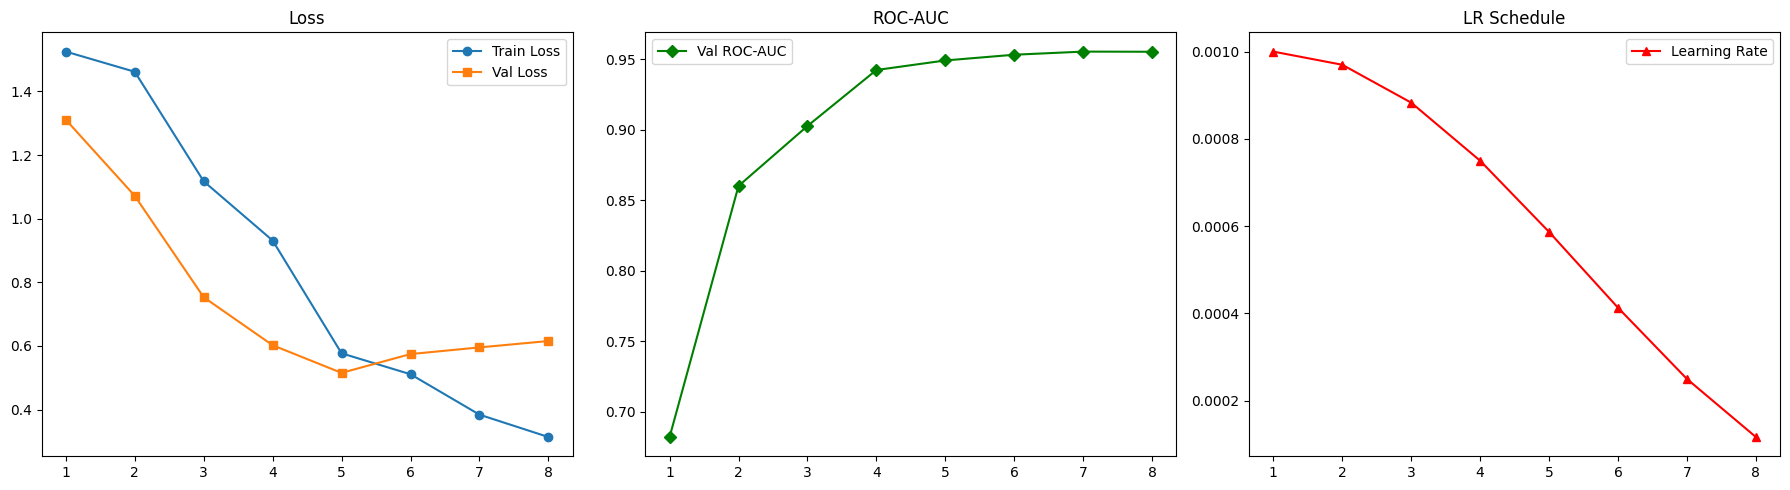


############################################################
# Training model: bilstm
############################################################
Using device: cuda
Loading data...
Found 159571 rows, taking a random sample of 10000 for training...
Initializing tokenizers...
Building bilstm model...
Trainable parameters: 6,277,382

Class weights applied to handle highly imbalanced data:
  toxic               : 9.62
  severe_toxic        : 97.04
  obscene             : 17.69
  threat              : 499.00
  insult              : 18.57
  identity_hate       : 108.89

Starting training for bilstm...


Epoch 1/10: 100%|██████████| 250/250 [01:43<00:00,  2.41it/s, loss=2.0192]



Epoch 1 Summary:
  Train Loss: 1.3844 | Val Loss: 1.8969 | Val ROC-AUC: 0.8138


Epoch 2/10: 100%|██████████| 250/250 [01:43<00:00,  2.41it/s, loss=0.9041]



Epoch 2 Summary:
  Train Loss: 1.1680 | Val Loss: 1.4649 | Val ROC-AUC: 0.8945
  ✅ EarlyStopping: metric improved


...


Epoch 4 Summary:
  Train Loss: 0.6505 | Val Loss: 1.2683 | Val ROC-AUC: 0.9353
  ⏳ EarlyStopping: 1/3 (no improvement)


Epoch 5/10: 100%|██████████| 250/250 [01:44<00:00,  2.40it/s, loss=0.0914]



Epoch 5 Summary:
  Train Loss: 0.5576 | Val Loss: 1.3872 | Val ROC-AUC: 0.9464
  ⏳ EarlyStopping: 2/3 (no improvement)


Epoch 6/10: 100%|██████████| 250/250 [01:43<00:00,  2.41it/s, loss=0.0800]



Epoch 6 Summary:
  Train Loss: 0.4547 | Val Loss: 1.3982 | Val ROC-AUC: 0.9505
  ⏳ EarlyStopping: 3/3 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 6!

FINAL EVALUATION ON VALIDATION SET (Best Model)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.27      0.88      0.41       186
 severe_toxic       0.08      1.00      0.15        16
      obscene       0.23      0.84      0.37       109
       threat       0.00      0.00      0.00         7
       insult       0.20      0.89      0.33       103
identity_hate       0.10      0.92      0.18        25

    micro avg       0.20      0.87      0.33       446
    macro avg       0.15      0.76      0.24       446
 weighted avg       0.22      0.87      0.35       446
  samples avg       0.05      0.08      0.06       446


Per-Class ROC-AUC:
  toxic               : 0.9021
  severe_toxic        : 0.9724
  obscene             : 0

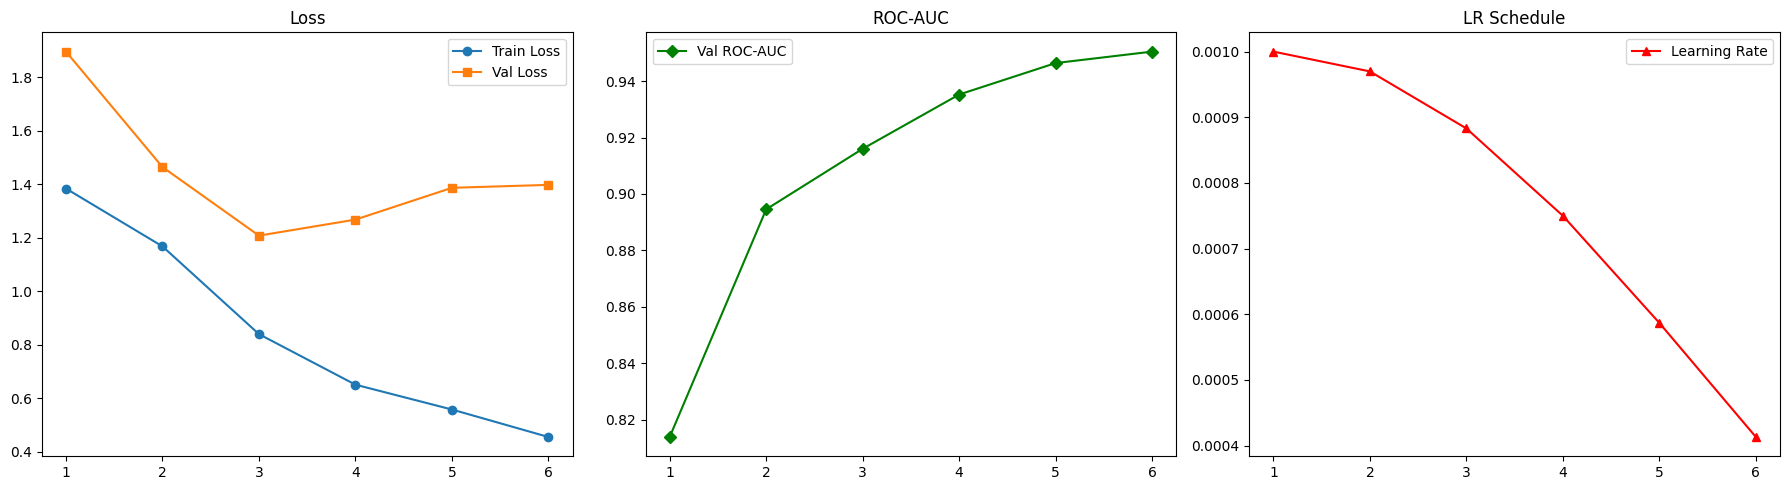


############################################################
# Training model: attention_bilstm
############################################################
Using device: cuda
Loading data...
Found 159571 rows, taking a random sample of 10000 for training...
Initializing tokenizers...
Building attention_bilstm model...
Trainable parameters: 6,540,550

Class weights applied to handle highly imbalanced data:
  toxic               : 9.62
  severe_toxic        : 97.04
  obscene             : 17.69
  threat              : 499.00
  insult              : 18.57
  identity_hate       : 108.89

Starting training for attention_bilstm...


Epoch 1/10: 100%|██████████| 250/250 [01:43<00:00,  2.41it/s, loss=4.9769]



Epoch 1 Summary:
  Train Loss: 1.4464 | Val Loss: 1.4070 | Val ROC-AUC: 0.7832


Epoch 2/10: 100%|██████████| 250/250 [01:43<00:00,  2.41it/s, loss=0.2292]



Epoch 2 Summary:
  Train Loss: 1.1015 | Val Loss: 1.2165 | Val ROC-AUC: 0.8858
  ✅ EarlyStopping: metric improved


...


Epoch 3 Summary:
  Train Loss: 0.7694 | Val Loss: 1.2551 | Val ROC-AUC: 0.9157
  ⏳ EarlyStopping: 1/3 (no improvement)


Epoch 4/10: 100%|██████████| 250/250 [01:44<00:00,  2.39it/s, loss=0.3431]



Epoch 4 Summary:
  Train Loss: 0.4785 | Val Loss: 1.3022 | Val ROC-AUC: 0.9384
  ⏳ EarlyStopping: 2/3 (no improvement)


Epoch 5/10: 100%|██████████| 250/250 [01:45<00:00,  2.37it/s, loss=0.2332]



Epoch 5 Summary:
  Train Loss: 0.3119 | Val Loss: 1.2243 | Val ROC-AUC: 0.9483
  ⏳ EarlyStopping: 3/3 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 5!

FINAL EVALUATION ON VALIDATION SET (Best Model)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.32      0.75      0.45       191
 severe_toxic       0.04      1.00      0.09        12
      obscene       0.27      0.87      0.41       118
       threat       0.07      0.20      0.11         5
       insult       0.22      0.83      0.34       108
identity_hate       0.04      0.71      0.07        17

    micro avg       0.20      0.80      0.32       451
    macro avg       0.16      0.73      0.24       451
 weighted avg       0.26      0.80      0.38       451
  samples avg       0.04      0.08      0.05       451


Per-Class ROC-AUC:
  toxic               : 0.8900
  severe_toxic        : 0.9905
  obscene             : 0

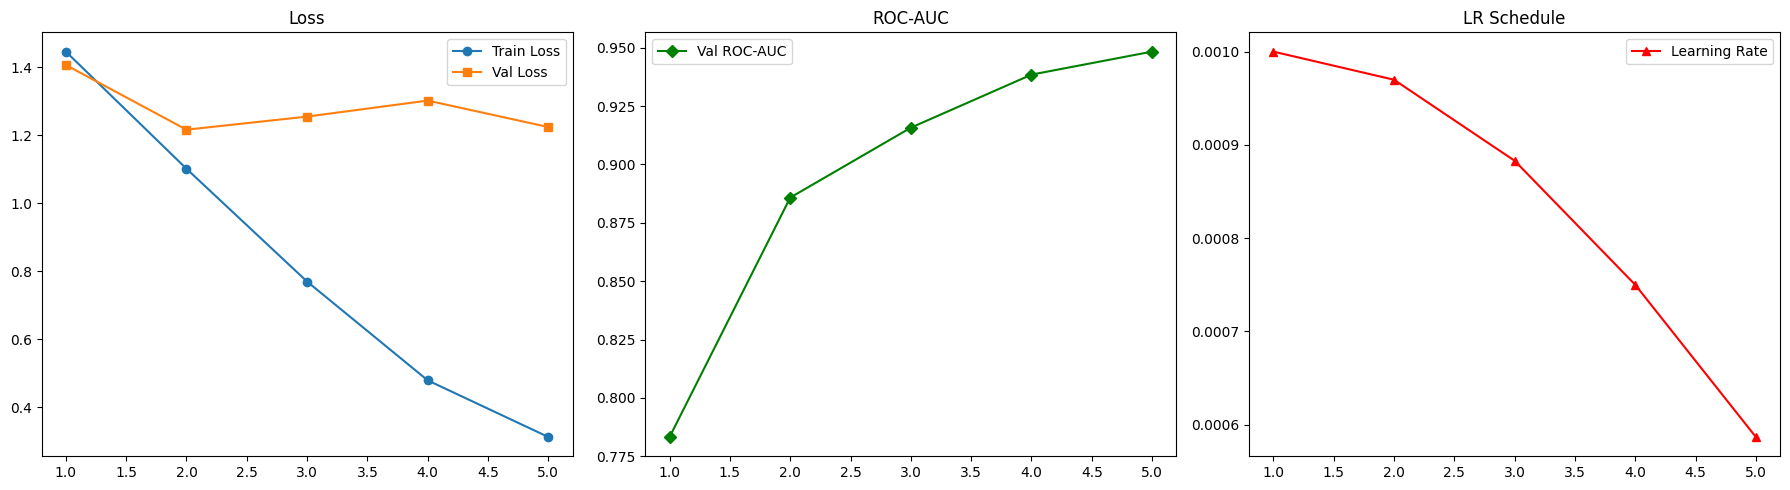


############################################################
# Training model: attention_lstm
############################################################
Using device: cuda
Loading data...
Found 159571 rows, taking a random sample of 10000 for training...
Initializing tokenizers...
Building attention_lstm model...
Trainable parameters: 4,896,006

Class weights applied to handle highly imbalanced data:
  toxic               : 9.62
  severe_toxic        : 97.04
  obscene             : 17.69
  threat              : 499.00
  insult              : 18.57
  identity_hate       : 108.89

Starting training for attention_lstm...


Epoch 1/10: 100%|██████████| 250/250 [00:57<00:00,  4.39it/s, loss=0.6194]



Epoch 1 Summary:
  Train Loss: 1.2145 | Val Loss: 0.9438 | Val ROC-AUC: 0.8686


Epoch 2/10: 100%|██████████| 250/250 [00:56<00:00,  4.44it/s, loss=0.3485]



Epoch 2 Summary:
  Train Loss: 0.9272 | Val Loss: 0.8991 | Val ROC-AUC: 0.9136
  ✅ EarlyStopping: metric improved


...


Epoch 3 Summary:
  Train Loss: 0.6174 | Val Loss: 0.9907 | Val ROC-AUC: 0.9267
  ⏳ EarlyStopping: 1/3 (no improvement)


Epoch 4/10: 100%|██████████| 250/250 [00:56<00:00,  4.43it/s, loss=0.3770]



Epoch 4 Summary:
  Train Loss: 0.3425 | Val Loss: 1.1594 | Val ROC-AUC: 0.9195
  ⏳ EarlyStopping: 2/3 (no improvement)


Epoch 5/10: 100%|██████████| 250/250 [00:56<00:00,  4.45it/s, loss=0.0358]



Epoch 5 Summary:
  Train Loss: 0.2458 | Val Loss: 1.3828 | Val ROC-AUC: 0.9289
  ⏳ EarlyStopping: 3/3 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 5!

FINAL EVALUATION ON VALIDATION SET (Best Model)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.48      0.73      0.58       189
 severe_toxic       0.23      0.91      0.36        22
      obscene       0.48      0.81      0.61       102
       threat       0.02      0.25      0.04         4
       insult       0.41      0.76      0.53        94
identity_hate       0.08      0.64      0.14        14

    micro avg       0.37      0.76      0.50       425
    macro avg       0.28      0.68      0.38       425
 weighted avg       0.44      0.76      0.55       425
  samples avg       0.04      0.07      0.05       425


Per-Class ROC-AUC:
  toxic               : 0.9234
  severe_toxic        : 0.9831
  obscene             : 0

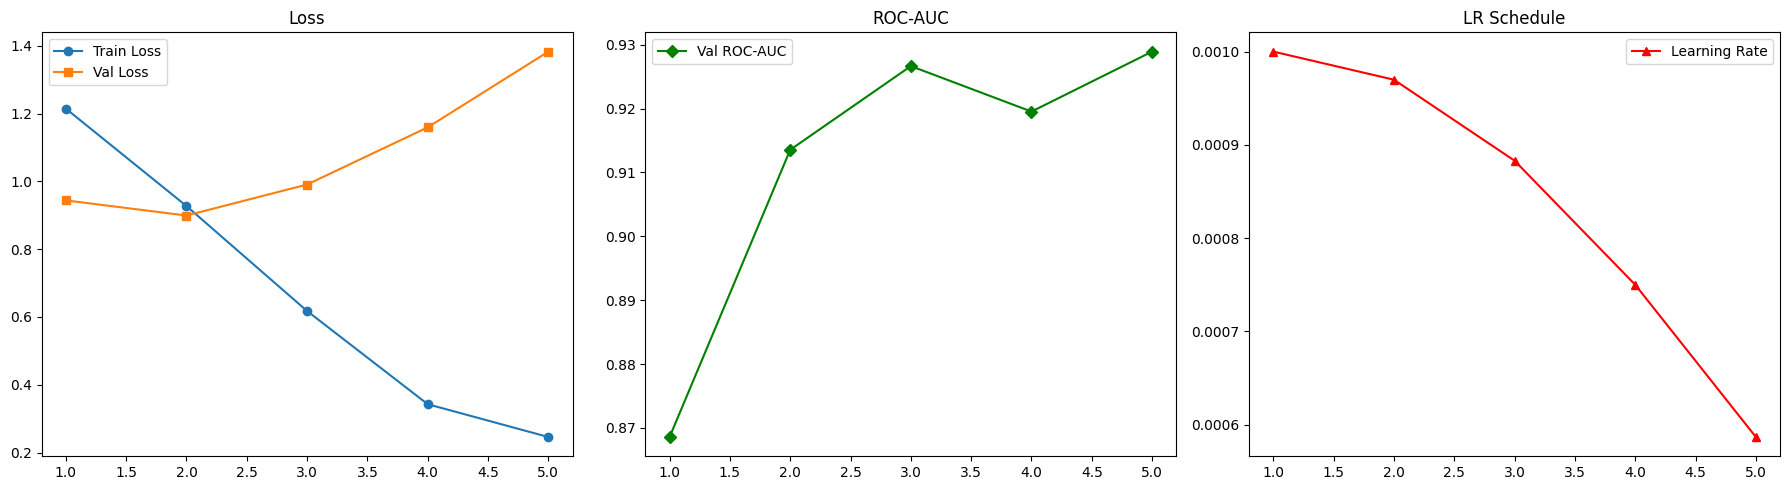


############################################################
# Training model: gru
############################################################
Using device: cuda
Loading data...
Found 159571 rows, taking a random sample of 10000 for training...
Initializing tokenizers...
Building gru model...
Trainable parameters: 4,599,558

Class weights applied to handle highly imbalanced data:
  toxic               : 9.62
  severe_toxic        : 97.04
  obscene             : 17.69
  threat              : 499.00
  insult              : 18.57
  identity_hate       : 108.89

Starting training for gru...


Epoch 1/10: 100%|██████████| 250/250 [01:14<00:00,  3.34it/s, loss=11.3534]



Epoch 1 Summary:
  Train Loss: 1.4935 | Val Loss: 1.7767 | Val ROC-AUC: 0.8573


Epoch 2/10: 100%|██████████| 250/250 [01:14<00:00,  3.33it/s, loss=0.7136]



Epoch 2 Summary:
  Train Loss: 1.0072 | Val Loss: 1.2793 | Val ROC-AUC: 0.9046
  ✅ EarlyStopping: metric improved


...


Epoch 4 Summary:
  Train Loss: 0.4512 | Val Loss: 1.1342 | Val ROC-AUC: 0.9344
  ⏳ EarlyStopping: 1/3 (no improvement)


Epoch 5/10: 100%|██████████| 250/250 [01:14<00:00,  3.35it/s, loss=4.2306]



Epoch 5 Summary:
  Train Loss: 0.3391 | Val Loss: 1.3434 | Val ROC-AUC: 0.9420
  ⏳ EarlyStopping: 2/3 (no improvement)


Epoch 6/10: 100%|██████████| 250/250 [01:14<00:00,  3.36it/s, loss=0.1106]



Epoch 6 Summary:
  Train Loss: 0.1949 | Val Loss: 1.5163 | Val ROC-AUC: 0.9441
  ⏳ EarlyStopping: 3/3 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 6!

FINAL EVALUATION ON VALIDATION SET (Best Model)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.44      0.85      0.58       208
 severe_toxic       0.21      0.93      0.35        28
      obscene       0.42      0.86      0.56       123
       threat       0.04      0.75      0.07         4
       insult       0.36      0.83      0.50       115
identity_hate       0.14      0.68      0.23        28

    micro avg       0.34      0.84      0.48       506
    macro avg       0.27      0.82      0.38       506
 weighted avg       0.39      0.84      0.52       506
  samples avg       0.05      0.09      0.06       506


Per-Class ROC-AUC:
  toxic               : 0.9334
  severe_toxic        : 0.9798
  obscene             : 0

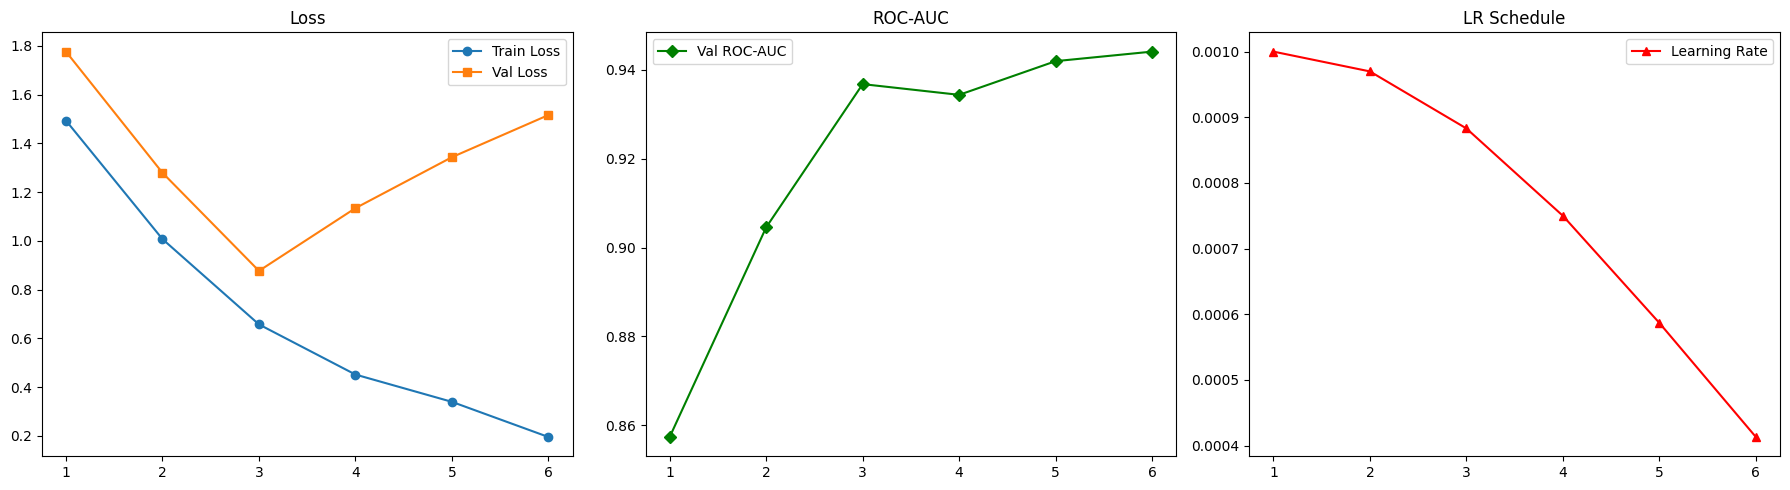


############################################################
# Training model: rcnn
############################################################
Using device: cuda
Loading data...
Found 159571 rows, taking a random sample of 10000 for training...
Initializing tokenizers...
Building rcnn model...
Trainable parameters: 6,605,574

Class weights applied to handle highly imbalanced data:
  toxic               : 9.62
  severe_toxic        : 97.04
  obscene             : 17.69
  threat              : 499.00
  insult              : 18.57
  identity_hate       : 108.89

Starting training for rcnn...


Epoch 1/10: 100%|██████████| 250/250 [01:45<00:00,  2.38it/s, loss=2.2280]



Epoch 1 Summary:
  Train Loss: 1.5783 | Val Loss: 1.3013 | Val ROC-AUC: 0.8302


Epoch 2/10: 100%|██████████| 250/250 [01:44<00:00,  2.39it/s, loss=0.3179]



Epoch 2 Summary:
  Train Loss: 1.3690 | Val Loss: 0.7119 | Val ROC-AUC: 0.9372
  ✅ EarlyStopping: metric improved


...


Epoch 3 Summary:
  Train Loss: 0.9794 | Val Loss: 0.8738 | Val ROC-AUC: 0.9578
  ⏳ EarlyStopping: 1/3 (no improvement)


Epoch 4/10: 100%|██████████| 250/250 [01:43<00:00,  2.41it/s, loss=0.1344]



Epoch 4 Summary:
  Train Loss: 0.7178 | Val Loss: 0.8778 | Val ROC-AUC: 0.9653
  ⏳ EarlyStopping: 2/3 (no improvement)


Epoch 5/10: 100%|██████████| 250/250 [01:43<00:00,  2.42it/s, loss=0.1349]



Epoch 5 Summary:
  Train Loss: 0.5260 | Val Loss: 0.9150 | Val ROC-AUC: 0.9663
  ⏳ EarlyStopping: 3/3 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 5!

FINAL EVALUATION ON VALIDATION SET (Best Model)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.29      0.82      0.43       184
 severe_toxic       0.13      0.94      0.22        17
      obscene       0.29      0.87      0.43        98
       threat       0.02      0.50      0.04         4
       insult       0.19      0.77      0.30        90
identity_hate       0.08      0.59      0.14        17

    micro avg       0.22      0.81      0.34       410
    macro avg       0.17      0.75      0.26       410
 weighted avg       0.25      0.81      0.38       410
  samples avg       0.04      0.07      0.05       410


Per-Class ROC-AUC:
  toxic               : 0.9071
  severe_toxic        : 0.9910
  obscene             : 0

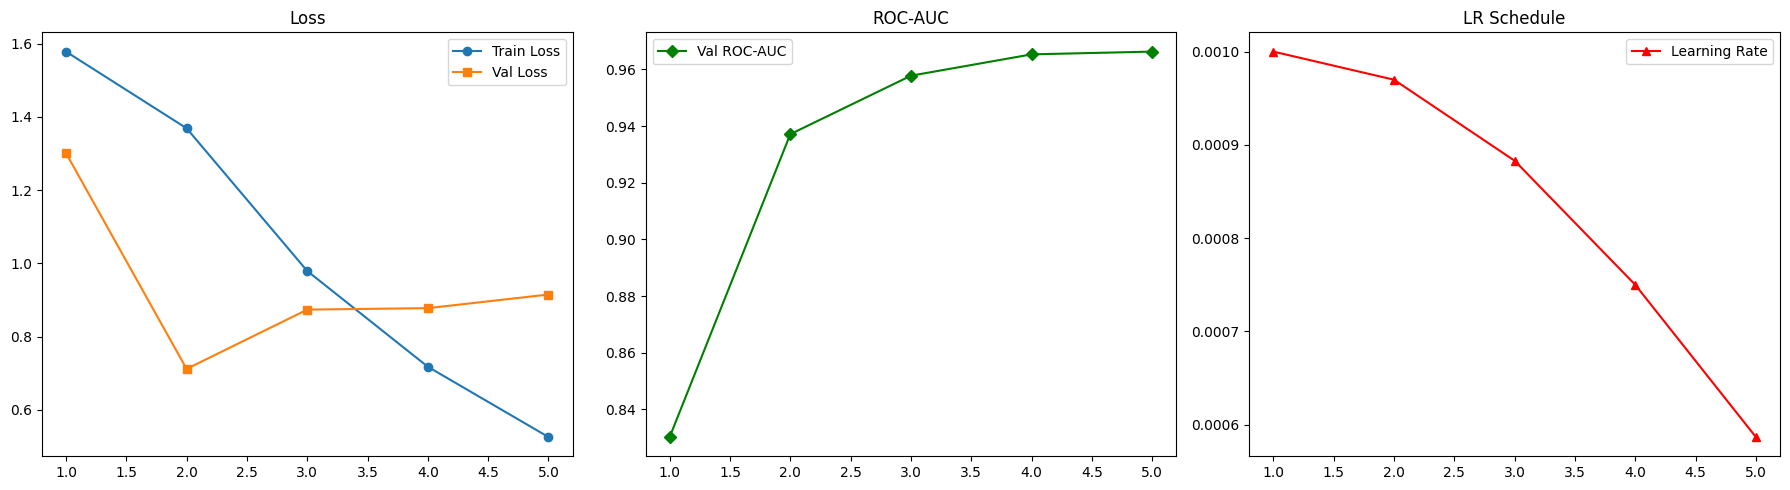


############################################################
# Training model: transformer
############################################################
Using device: cuda
Loading data...
Found 159571 rows, taking a random sample of 10000 for training...
Initializing tokenizers...
Building transformer model...
Trainable parameters: 4,304,134

Class weights applied to handle highly imbalanced data:
  toxic               : 9.62
  severe_toxic        : 97.04
  obscene             : 17.69
  threat              : 499.00
  insult              : 18.57
  identity_hate       : 108.89

Starting training for transformer...


Epoch 1/10: 100%|██████████| 250/250 [00:12<00:00, 20.23it/s, loss=9.0832]



Epoch 1 Summary:
  Train Loss: 1.4821 | Val Loss: 1.6740 | Val ROC-AUC: 0.8328


Epoch 2/10: 100%|██████████| 250/250 [00:12<00:00, 20.24it/s, loss=0.2304]



Epoch 2 Summary:
  Train Loss: 1.0581 | Val Loss: 1.5427 | Val ROC-AUC: 0.8964
  ✅ EarlyStopping: metric improved


...


Epoch 4 Summary:
  Train Loss: 0.7186 | Val Loss: 1.1022 | Val ROC-AUC: 0.9380
  ⏳ EarlyStopping: 1/3 (no improvement)


Epoch 5/10: 100%|██████████| 250/250 [00:12<00:00, 20.27it/s, loss=0.6470]



Epoch 5 Summary:
  Train Loss: 0.6344 | Val Loss: 1.1574 | Val ROC-AUC: 0.9429
  ⏳ EarlyStopping: 2/3 (no improvement)


Epoch 6/10: 100%|██████████| 250/250 [00:12<00:00, 20.14it/s, loss=0.2569]



Epoch 6 Summary:
  Train Loss: 0.5202 | Val Loss: 1.3775 | Val ROC-AUC: 0.9426
  ⏳ EarlyStopping: 3/3 (no improvement)
  🛑 EarlyStopping triggered! Restoring best model...

🛑 Early stopping triggered at epoch 6!

FINAL EVALUATION ON VALIDATION SET (Best Model)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

        toxic       0.43      0.74      0.55       185
 severe_toxic       0.29      0.92      0.44        24
      obscene       0.60      0.80      0.69       102
       threat       0.01      0.20      0.03         5
       insult       0.54      0.76      0.63       101
identity_hate       0.12      0.71      0.21        17

    micro avg       0.39      0.76      0.52       434
    macro avg       0.33      0.69      0.42       434
 weighted avg       0.47      0.76      0.58       434
  samples avg       0.05      0.06      0.05       434


Per-Class ROC-AUC:
  toxic               : 0.9134
  severe_toxic        : 0.9842
  obscene             : 0

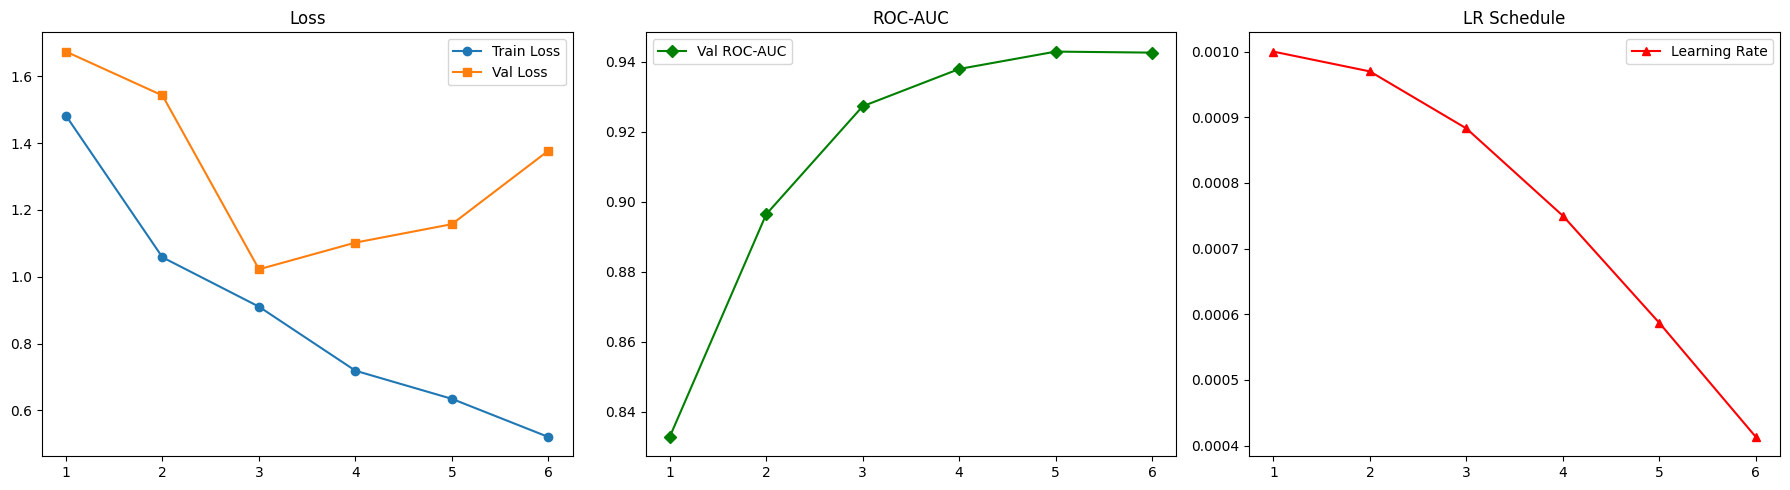


MODEL COMPARISON RESULTS
Model                  Best Val AUC    Final AUC    F1 Macro     F1 Micro    
----------------------------------------------------------------------
lstm                   0.9555          0.9554       0.4354       0.5484      
bilstm                 0.9505          0.9505       0.4106       0.5081      
attention_bilstm       0.9483          0.9483       0.3842       0.5260      
attention_lstm         0.9289          0.9289       0.4285       0.5655      
gru                    0.9441          0.9441       0.4847       0.5952      
rcnn                   0.9663          0.9663       0.4312       0.5972      
transformer            0.9429          0.9426       0.4934       0.6163      

 BEST MODEL: rcnn (Val ROC-AUC = 0.9663)
Generating submission with best model...

Generating submission to submission.csv...


Submission file saved as 'submission.csv'.


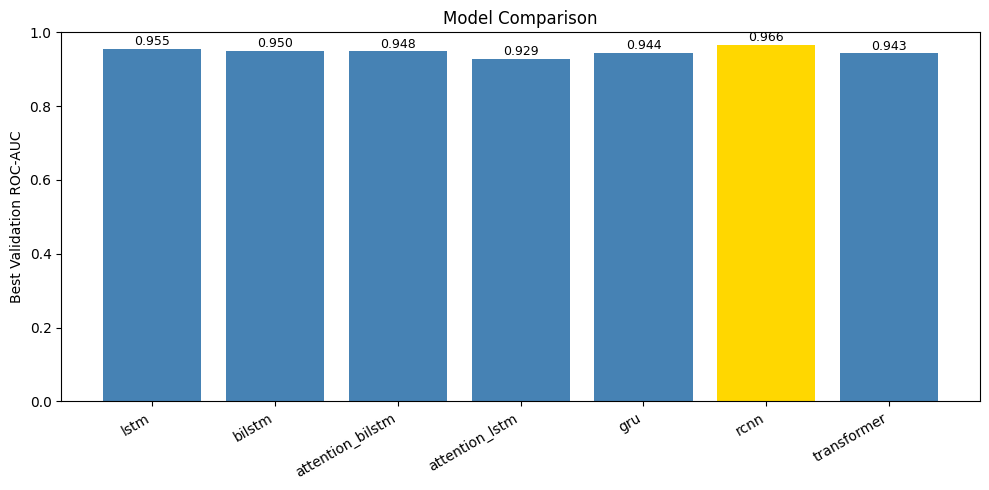


Submission saved to 'submission.csv'
Done!


In [9]:
def run_all_models(sample_size=None):
    """Train all models, evaluate them, and pick the best one for submission."""
    ALL_MODELS = [
        LSTM_MODEL,
        BILSTM_MODEL,
        ATTENTION_BILSTM_MODEL,
        'attention_lstm',
        GRU_MODEL,
        RCNN_MODEL,
        TRANSFORMER_MODEL,
    ]

    results = {}
    for model_type in ALL_MODELS:
        print("\n" + "#" * 60)
        print(f"# Training model: {model_type}")
        print("#" * 60)
        try:
            result = main(model_type=model_type, sample_size=sample_size)
            results[model_type] = result
        except Exception as e:
            print(f"  ERROR training {model_type}: {e}")
            results[model_type] = None

    # ========== Comparison Table ==========
    print("\n" + "=" * 70)
    print("MODEL COMPARISON RESULTS")
    print("=" * 70)
    header = f"{'Model':<22} {'Best Val AUC':<15} {'Final AUC':<12} {'F1 Macro':<12} {'F1 Micro':<12}"
    print(header)
    print("-" * 70)

    best_model_type = None
    best_auc = -1.0

    for model_type, res in results.items():
        if res is None:
            print(f"{model_type:<22} FAILED")
            continue
        auc = res['best_val_auc']
        print(f"{model_type:<22} {auc:<15.4f} {res['final_val_auc']:<12.4f} {res['final_f1_macro']:<12.4f} {res['final_f1_micro']:<12.4f}")
        if auc > best_auc:
            best_auc = auc
            best_model_type = model_type

    print("=" * 70)

    if best_model_type is None:
        print("No model trained successfully.")
        return

    print(f"\n BEST MODEL: {best_model_type} (Val ROC-AUC = {best_auc:.4f})")
    print(f"Generating submission with best model...\n")

    best = results[best_model_type]
    generate_submission(best['model'], best['processor'], best['device'], SUBMISSION_CSV_PATH)

    # ========== Summary plot ==========
    model_names = []
    aucs = []
    for m, res in results.items():
        if res is not None:
            model_names.append(m)
            aucs.append(res['best_val_auc'])

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(model_names, aucs, color=['gold' if m == best_model_type else 'steelblue' for m in model_names])
    ax.set_ylabel('Best Validation ROC-AUC')
    ax.set_title('Model Comparison')
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nSubmission saved to '{SUBMISSION_CSV_PATH}'")
    print("Done!")


# ==========================================
# Run ALL models and pick the best for submission
# Set sample_size=10000 for quick testing, or None for full dataset
# ==========================================
run_all_models(sample_size=10000)
